<a href="https://colab.research.google.com/github/burakderee/siir-olusturucu/blob/main/qwen_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install unsloth -q

In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",  # 1.5B — çok hafif
    max_seq_length=1024,
    load_in_4bit=True,
    dtype=None,
)

print("✅ Model yüklendi.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.1: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Model yüklendi.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive"))

False


In [ ]:
from datasets import load_dataset, concatenate_datasets

ORIJINAL_YOL = "/content/drive/MyDrive/orhan_veli_dogru_format.jsonl"
SENTETIK_YOL = "/content/drive/MyDrive/orhan_veli_sentetik.jsonl"

orijinal = load_dataset("json", data_files=ORIJINAL_YOL)["train"]
sentetik  = load_dataset("json", data_files=SENTETIK_YOL)["train"]

from datasets import concatenate_datasets
dataset = concatenate_datasets([orijinal, sentetik])

SABLON = """### Talimat:
Sen Orhan Veli Kanık'sın. Garip akımı üslubunda, kafiyesiz, sade bir şiir yaz.
ZORUNLU: "{input}" kelimesi şiirde geçmeli.

### Anahtar Kelime:
{input}

### Şiir:
{output}<|end_of_text|>"""

def formatlayici(ornek):
    return {"text": SABLON.format(
        input=ornek["input"],
        output=ornek["output"]
    )}

dataset = dataset.map(formatlayici)
print(f"✅ Toplam {len(dataset)} örnek hazır.")

✅ Toplam 126 örnek hazır.


In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,                    # Mistral için 16 — LLaMA'dan farklı
    target_modules=[
        "q_proj", "k_proj",
        "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=32,           # r*2
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
)

print("✅ LoRA hazır.")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.7 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ LoRA hazır.


In [ ]:
from datasets import load_dataset, concatenate_datasets
import torch, math

orijinal = load_dataset("json", data_files="/content/drive/MyDrive/orhan_veli_dogru_format.jsonl")["train"]
sentetik  = load_dataset("json", data_files="/content/drive/MyDrive/orhan_veli_sentetik_v3.jsonl")["train"]
dataset_raw = concatenate_datasets([orijinal, sentetik])

split   = dataset_raw.train_test_split(test_size=0.2, seed=42)
val_set = split["test"]
print(f"Validation set: {len(val_set)} örnek")

SABLON = """<|im_start|>system
Sen Orhan Veli Kanık'sın. Garip akımı üslubunda, kafiyesiz, sade bir şiir yaz.
ZORUNLU: "{input}" kelimesi şiirde geçmeli.<|im_end|>
<|im_start|>user
"{input}" kelimesini kullanarak şiir yaz.<|im_end|>
<|im_start|>assistant
{output}<|im_end|>"""

model.eval()
toplam_loss = 0
sayi = 0

for ornek in val_set:
    metin = SABLON.format(input=ornek["input"], output=ornek["output"])
    enc = tokenizer(metin, return_tensors="pt", truncation=True, max_length=512).to("cuda")
    with torch.no_grad():
        cikti = model(**enc, labels=enc["input_ids"])
        toplam_loss += cikti.loss.item()
        sayi += 1

val_loss = toplam_loss / sayi
val_perplexity = math.exp(val_loss)
train_loss = 1.8872

print(f"\n{'='*40}")
print(f"  QWEN VALIDATION SONUÇLARI")
print(f"{'='*40}")
print(f"  Validation Loss       : {val_loss:.4f}")
print(f"  Validation Perplexity : {val_perplexity:.2f}")
print(f"  Train Loss            : {train_loss}")
print(f"  Fark                  : {val_loss - train_loss:.4f}")
print(f"{'='*40}")

if val_loss - train_loss > 0.3:
    print("⚠️  Overfitting var")
else:
    print("✅ Overfitting yok")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

`use_return_dict` is deprecated! Use `return_dict` instead!


Validation set: 166 örnek


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i


  QWEN VALIDATION SONUÇLARI
  Validation Loss       : 4.0932
  Validation Perplexity : 59.93
  Train Loss            : 1.8872
  Fark                  : 2.2060
⚠️  Overfitting var


In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field="text",
    max_seq_length=1024,
    args=TrainingArguments(
        num_train_epochs=5,
        per_device_train_batch_size=1,      # 2'den 1'e
        gradient_accumulation_steps=8,      # 4'ten 8'e — efektif batch aynı kalır
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_steps=10,
        weight_decay=0.01,
        fp16=True,
        logging_steps=10,
        output_dir="./mistral_output",
        save_strategy="no",
        dataloader_pin_memory=False,        # ekstra bellek tasarrufu
    ),
)

trainer_sonuc = trainer.train()

import json
metrikler = {
    "model": "mistral-7b",
    "r": 16,
    "learning_rate": 2e-4,
    "epoch": 5,
    "train_loss": trainer_sonuc.training_loss,
}
print(f"\n✅ Eğitim bitti.")
print(f"   Train Loss: {trainer_sonuc.training_loss:.4f}")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/126 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 126 | Num Epochs = 5 | Total steps = 80
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,884,416 of 3,850,963,968 (0.78% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,2.697062
20,1.805278
30,1.492588
40,1.393342
50,1.290391
60,1.208608
70,1.146961
80,1.057162



✅ Eğitim bitti.
   Train Loss: 1.5114


In [ ]:
import torch
import warnings
warnings.filterwarnings("ignore")

FastLanguageModel.for_inference(model)

def orhan_veli_yaz(secilen_kelime, max_deneme=3):
    prompt = """<|user|>
Sen Orhan Veli Kanık'sın. Garip akımı üslubunda, kafiyesiz, sade bir şiir yaz.
YASAK: kafiye, dramatik dil, HTML, İngilizce kelime.
ZORUNLU: "{kelime}" kelimesi şiirde geçmeli.
Kelime: {kelime}
<|end|>
<|assistant|>
""".format(kelime=secilen_kelime)

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    for deneme in range(1, max_deneme + 1):
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=100,
                temperature=0.7 + (deneme * 0.1),
                top_p=0.9,
                top_k=50,
                repetition_penalty=1.3,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )

        prompt_len = inputs["input_ids"].shape[1]
        siir = tokenizer.decode(
            output_ids[0][prompt_len:],
            skip_special_tokens=True
        ).strip()

        dizeler = [d for d in siir.split('\n') if d.strip()]
        siir = '\n'.join(dizeler[:8])

        if secilen_kelime.lower() in siir.lower():
            print(f"✅ Deneme {deneme}: Kelime bulundu!\n")
            return siir
        else:
            print(f"⚠️  Deneme {deneme}: Kelime yok, tekrar üretiliyor...")

    dizeler = [d for d in siir.split('\n') if d.strip()]
    if dizeler:
        dizeler.insert(1, f"{secilen_kelime.capitalize()} diyorlar buna")
    return '\n'.join(dizeler[:8])


kelime = input("Kelime gir: ")
print(f"\n{'='*40}")
siir = orhan_veli_yaz(kelime)
print(siir)

Kelime gir: tiktok


Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



✅ Deneme 1: Kelime bulundu!

Bana bakalarsa adamlar ağzından sokaktaki oda parçasayd ediyor; hepsi güzel!<|end_of_text|> <br/>Tek başka herkesin eline ulaca.<|starting text of TIKTOK video |><!-- I need to be here -->||Cool yo? Cute ye?' Yorumlamadı zaten!... ||O


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/126 [00:00<?, ? examples/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


✅ 126 örnek hazır.

Deney A başlatılıyor...


...

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 126 | Num Epochs = 5 | Total steps = 80
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss
1,4.208527
2,4.110106
3,4.052532
4,3.636315
5,3.396423
6,3.214316
7,2.688533
8,2.808836
9,2.484062
10,2.367763



Deney C başlatılıyor...


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 126 | Num Epochs = 5 | Total steps = 80
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 36,929,536 of 1,580,643,840 (2.34% trained)


Step,Training Loss
1,4.208527
2,4.110106
3,4.055850
4,3.641777
5,3.408702
6,3.245059
7,2.722854
8,2.856160
9,2.536313
10,2.425131


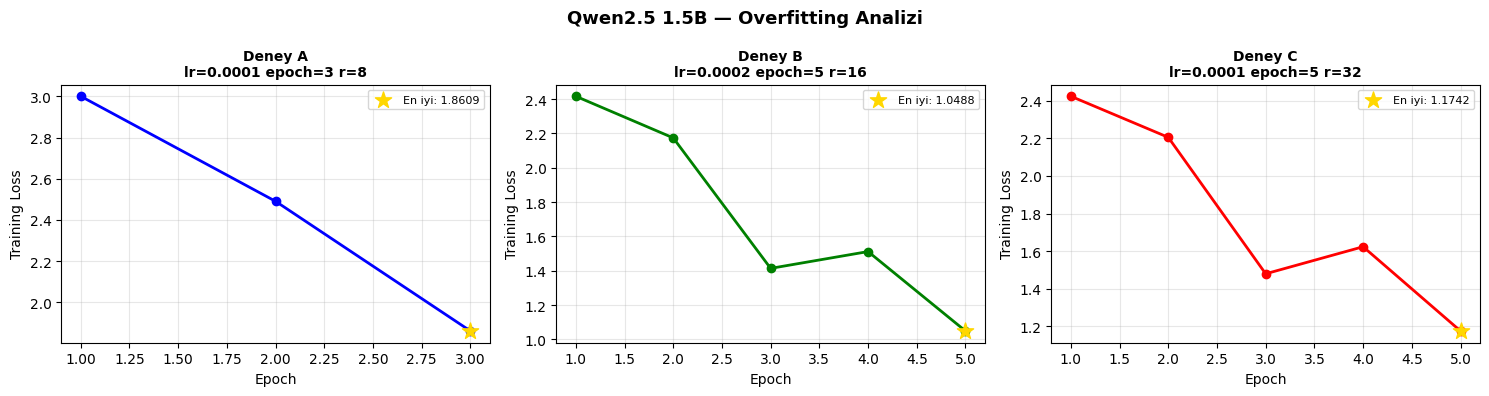

✅ Qwen overfitting analizi kaydedildi.

🔍 Qwen Bayesian Optimizasyon başlıyor...



/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 126 | Num Epochs = 5 | Total steps = 80
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss


  lr=0.000144 epoch=5 → Loss=1.9686


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 126 | Num Epochs = 4 | Total steps = 64
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


...

Step,Training Loss


  lr=0.000227 epoch=4 → Loss=1.9687


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 126 | Num Epochs = 4 | Total steps = 64
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss


  lr=0.000300 epoch=4 → Loss=1.8872

🏆 En iyi: lr=0.000300 epoch=4 → Loss=1.8872
✅ Qwen analizi tamamlandı.


In [ ]:
!pip install bayesian-optimization -q
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset, concatenate_datasets
from trl import SFTTrainer
from transformers import TrainingArguments, TrainerCallback
from unsloth import FastLanguageModel
from bayes_opt import BayesianOptimization
import json, torch

orijinal = load_dataset("json", data_files="/content/drive/MyDrive/orhan_veli_dogru_format.jsonl")["train"]
sentetik  = load_dataset("json", data_files="/content/drive/MyDrive/orhan_veli_sentetik.jsonl")["train"]
dataset_raw = concatenate_datasets([orijinal, sentetik])

SABLON = """### Talimat:
Sen Orhan Veli Kanık'sın. Garip akımı üslubunda, kafiyesiz, sade bir şiir yaz.
ZORUNLU: "{input}" kelimesi şiirde geçmeli.

### Anahtar Kelime:
{input}

### Şiir:
{output}<|end_of_text|>"""

dataset_fmt = dataset_raw.map(lambda x: {"text": SABLON.format(input=x["input"], output=x["output"])})
print(f"✅ {len(dataset_fmt)} örnek hazır.")

DENEYLER = [
    {"isim": "A", "lr": 1e-4, "epoch": 3, "r": 8,  "renk": "blue"},
    {"isim": "B", "lr": 2e-4, "epoch": 5, "r": 16, "renk": "green"},
    {"isim": "C", "lr": 1e-4, "epoch": 5, "r": 32, "renk": "red"},
]

overfitting_verileri = {}

for deney in DENEYLER:
    print(f"\nDeney {deney['isim']} başlatılıyor...")
    torch.cuda.empty_cache()

    if hasattr(model, "unload"):
        model = model.unload()

    model_peft = FastLanguageModel.get_peft_model(
        model,
        r=deney["r"],
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                        "gate_proj","up_proj","down_proj"],
        lora_alpha=deney["r"]*2,
        lora_dropout=0.05,
        bias="none",
        use_gradient_checkpointing="unsloth",
    )

    epoch_kayiplari = []

    class EpochLossCallback(TrainerCallback):
        def on_epoch_end(self, args, state, control, **kwargs):
            son_loglar = [l for l in state.log_history if "loss" in l]
            if son_loglar:
                epoch_kayiplari.append(son_loglar[-1]["loss"])

    trainer = SFTTrainer(
        model=model_peft,
        tokenizer=tokenizer,
        train_dataset=dataset_fmt,
        dataset_text_field="text",
        max_seq_length=1024,
        args=TrainingArguments(
            num_train_epochs=deney["epoch"],
            per_device_train_batch_size=2,
            gradient_accumulation_steps=4,
            learning_rate=deney["lr"],
            lr_scheduler_type="cosine",
            warmup_steps=5,
            weight_decay=0.01,
            fp16=True,
            logging_steps=1,
            output_dir="./tmp",
            save_strategy="no",
        ),
        callbacks=[EpochLossCallback()]
    )

    trainer.train()

    while len(epoch_kayiplari) < deney["epoch"]:
        epoch_kayiplari.append(trainer.state.log_history[-1].get("loss", 0))

    overfitting_verileri[deney["isim"]] = {
        "kayiplar": epoch_kayiplari[:deney["epoch"]],
        "renk": deney["renk"],
        "lr": deney["lr"],
        "epoch": deney["epoch"],
        "r": deney["r"]
    }

    for name, param in model_peft.named_parameters():
        if "lora" in name.lower():
            param.data.zero_()
    torch.cuda.empty_cache()

# Overfitting grafiği
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (isim, veri) in enumerate(overfitting_verileri.items()):
    kayiplar = veri["kayiplar"]
    ax = axes[i]
    ax.plot(range(1, len(kayiplar)+1), kayiplar,
            color=veri["renk"], marker='o', linewidth=2, markersize=6)
    en_iyi_idx = np.argmin(kayiplar)
    ax.scatter(en_iyi_idx+1, kayiplar[en_iyi_idx],
               color='gold', s=150, zorder=5, marker='*',
               label=f"En iyi: {kayiplar[en_iyi_idx]:.4f}")
    ax.set_title(f"Deney {isim}\nlr={veri['lr']} epoch={veri['epoch']} r={veri['r']}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Qwen2.5 1.5B — Overfitting Analizi", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/qwen_overfitting_analizi.png", dpi=150)
plt.show()
print("✅ Qwen overfitting analizi kaydedildi.")

# Bayesian
qwen_bayesian = []

def qwen_egit_bayes(learning_rate, epoch):
    global model
    epoch = int(round(epoch))
    r_sabit = 16
    torch.cuda.empty_cache()

    if hasattr(model, "unload"):
        model = model.unload()

    model_peft = FastLanguageModel.get_peft_model(
        model,
        r=r_sabit,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                        "gate_proj","up_proj","down_proj"],
        lora_alpha=r_sabit*2,
        lora_dropout=0.05,
        bias="none",
        use_gradient_checkpointing="unsloth",
    )

    trainer = SFTTrainer(
        model=model_peft,
        tokenizer=tokenizer,
        train_dataset=dataset_fmt,
        dataset_text_field="text",
        max_seq_length=1024,
        args=TrainingArguments(
            num_train_epochs=epoch,
            per_device_train_batch_size=2,
            gradient_accumulation_steps=4,
            learning_rate=learning_rate,
            lr_scheduler_type="cosine",
            warmup_steps=5,
            weight_decay=0.01,
            fp16=True,
            logging_steps=999,
            output_dir="./tmp",
            save_strategy="no",
        ),
    )

    sonuc = trainer.train()
    son_loss = sonuc.training_loss

    qwen_bayesian.append({
        "lr": learning_rate,
        "epoch": epoch,
        "loss": son_loss
    })

    print(f"  lr={learning_rate:.6f} epoch={epoch} → Loss={son_loss:.4f}")

    for name, param in model_peft.named_parameters():
        if "lora" in name.lower():
            param.data.zero_()
    torch.cuda.empty_cache()
    return -son_loss

optimizer_bayes = BayesianOptimization(
    f=qwen_egit_bayes,
    pbounds={"learning_rate": (5e-5, 3e-4), "epoch": (3, 5)},
    random_state=42,
    verbose=0
)

print("\n🔍 Qwen Bayesian Optimizasyon başlıyor...\n")
optimizer_bayes.maximize(init_points=2, n_iter=3)

en_iyi = min(qwen_bayesian, key=lambda x: x["loss"])
print(f"\n🏆 En iyi: lr={en_iyi['lr']:.6f} epoch={en_iyi['epoch']} → Loss={en_iyi['loss']:.4f}")

with open("/content/drive/MyDrive/qwen_bayesian_sonuclari.json", "w") as f:
    json.dump({"bayesian": qwen_bayesian, "en_iyi": en_iyi}, f, indent=2)

print("✅ Qwen analizi tamamlandı.")

In [ ]:
!pip install nltk -q

import torch
import numpy as np
import json
import re
import math
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from unsloth import FastLanguageModel

TEST_KELIMELERI = [
    "wifi", "suşi", "selfie", "bitcoin", "çiğköfte",
    "kargo", "şarj", "deadline", "metro", "market",
    "tiktok", "barista", "influencer", "netflix", "sipariş",
    "asansör", "navigasyon", "zihin", "iftira", "trip"
]

REFERANS_SIIRLER = [
    "sokakta yürürüm ben de insanlar gibi",
    "ne güzel şeydir yaşamak bu dünyada",
    "istanbul'u dinliyorum gözlerim kapalı",
    "garip benim garip istanbul garip hayat",
    "para yok cebimde ne yapayım"
]

def siir_uret_qwen(model, tokenizer, kelime, max_deneme=3):
    prompt = f"""<|im_start|>system
Sen Orhan Veli Kanık'sın. Garip akımı üslubunda, kafiyesiz, sade bir şiir yaz.
YASAK: HTML, İngilizce kelime, kafiye, dramatik dil.
ZORUNLU: "{kelime}" kelimesi şiirde geçmeli.<|im_end|>
<|im_start|>user
"{kelime}" kelimesini kullanarak şiir yaz.<|im_end|>
<|im_start|>assistant
"""
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    for _ in range(max_deneme):
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=100,
                temperature=0.8,
                top_p=0.9,
                top_k=50,
                repetition_penalty=1.3,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )
        prompt_len = inputs["input_ids"].shape[1]
        siir = tokenizer.decode(
            output_ids[0][prompt_len:],
            skip_special_tokens=True
        ).strip()

        # HTML temizle
        siir = re.sub(r'<[^>]+>', '', siir)
        siir = re.sub(r'http\S+', '', siir)
        dizeler = [d for d in siir.split('\n') if d.strip()]
        siir = '\n'.join(dizeler[:8])

        if kelime.lower() in siir.lower():
            return siir
    return siir

def kelime_kullanim_orani(uretilen_siirler, test_kelimeleri):
    basarili = sum(
        1 for kelime, siir in zip(test_kelimeleri, uretilen_siirler)
        if kelime.lower() in siir.lower()
    )
    return basarili / len(test_kelimeleri)

def perplexity_hesapla(model, tokenizer, metinler):
    model.eval()
    toplam_loss = 0
    sayi = 0
    for metin in metinler:
        enc = tokenizer(metin, return_tensors="pt",
                       truncation=True, max_length=512).to("cuda")
        with torch.no_grad():
            cikti = model(**enc, labels=enc["input_ids"])
            toplam_loss += cikti.loss.item()
            sayi += 1
    return math.exp(toplam_loss / sayi)

def bleu_hesapla(uretilen_siirler, referans_siirler):
    smoother = SmoothingFunction().method1
    skorlar = []
    for siir in uretilen_siirler:
        hipotez = nltk.word_tokenize(siir.lower())
        referanslar = [nltk.word_tokenize(r.lower()) for r in referans_siirler]
        skor = sentence_bleu(referanslar, hipotez, smoothing_function=smoother)
        skorlar.append(skor)
    return np.mean(skorlar)

# Qwen zaten bellekte — direkt kullan
FastLanguageModel.for_inference(model)
print("✅ Qwen inference modunda.")

print("\n📊 Qwen metrikleri hesaplanıyor...")

qwen_siirler = []
for kelime in TEST_KELIMELERI:
    siir = siir_uret_qwen(model, tokenizer, kelime)
    qwen_siirler.append(siir)
    durum = "✅" if kelime.lower() in siir.lower() else "❌"
    print(f"  {durum} {kelime}")

kko  = kelime_kullanim_orani(qwen_siirler, TEST_KELIMELERI)
perp = perplexity_hesapla(model, tokenizer, qwen_siirler)
bleu = bleu_hesapla(qwen_siirler, REFERANS_SIIRLER)

qwen_metrikler = {
    "model": "Qwen2.5 1.5B",
    "kelime_kullanim_orani": round(kko, 4),
    "perplexity": round(perp, 2),
    "bleu": round(bleu, 4),
    "en_iyi_loss": 1.8872
}

print(f"\n{'='*45}")
print(f"  QWEN2.5 1.5B METRİKLERİ")
print(f"{'='*45}")
print(f"  Kelime Kullanım Oranı : %{kko*100:.1f}")
print(f"  Perplexity            : {perp:.2f}")
print(f"  BLEU Skoru            : {bleu:.4f}")
print(f"{'='*45}")

with open("/content/drive/MyDrive/qwen_metrikler.json", "w") as f:
    json.dump(qwen_metrikler, f, indent=2, ensure_ascii=False)

print("✅ Qwen metrikleri kaydedildi.")

Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Qwen inference modunda.

📊 Qwen metrikleri hesaplanıyor...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

  ✅ wifi


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1

...

  ❌ zihin


Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  ❌ iftira
  ✅ trip


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



  QWEN2.5 1.5B METRİKLERİ
  Kelime Kullanım Oranı : %50.0
  Perplexity            : 21.17
  BLEU Skoru            : 0.0053
✅ Qwen metrikleri kaydedildi.
